Import statements

In [2]:
import pandas as pd
import seaborn as sns
from scipy import stats

## Analysis Technique 1 - CM - What college should I attend to make the most money?

In [33]:
players = pd.read_csv('core/people.csv')
schools = pd.read_csv('core/Schools.csv')
salaries = pd.read_csv('core/Salaries.csv')
college_playing = pd.read_csv('core/CollegePlaying.csv')

In [27]:
# Goal: Group salaries by school. 
# So first I need to make each player have their average salary, 
# and then group players by school and then average the salaries for each school. 
# Then a bar chart with each school (maybe top 10 or something).

playersalaries = players.merge(salaries)
playersalaries = playersalaries.groupby('playerID')
# Calculate the average salary and reset the index to keep it as a clean DataFrame
average_salaries = playersalaries['salary'].mean().reset_index()

average_salaries


,playerID,salary
0,aardsda01,"1,322,821"
1,aasedo01,"575,000"
2,abadan01,"327,000"
3,abadfe01,"753,280"
4,abbotje01,"246,250"
...,...,...
5144,zumayjo01,"701,167"
5145,zuninmi01,"513,800"
5146,zupcibo01,"143,667"
5147,zuvelpa01,"145,000"


In [35]:
# Players often have multiple entries if they played multiple years. 
# Dropping duplicates ensures we just get one school per player.
player_schools = college_playing.drop_duplicates(subset=['playerID'])[['playerID', 'schoolID']]

# Merge using a left join to keep all players, even those without a school
matched_data = pd.merge(average_salaries, player_schools, on='playerID', how='left')

# Replace the missing (NaN) values in the school column with a custom group name
matched_data['schoolID'] = matched_data['schoolID'].fillna('Did Not Attend')

matched_data

,playerID,salary,schoolID
0,aardsda01,"1,322,821",pennst
1,aasedo01,"575,000",Did Not Attend
2,abadan01,"327,000",gamiddl
3,abadfe01,"753,280",Did Not Attend
4,abbotje01,"246,250",kentucky
...,...,...,...
5144,zumayjo01,"701,167",Did Not Attend
5145,zuninmi01,"513,800",florida
5146,zupcibo01,"143,667",oralrob
5147,zuvelpa01,"145,000",stanford


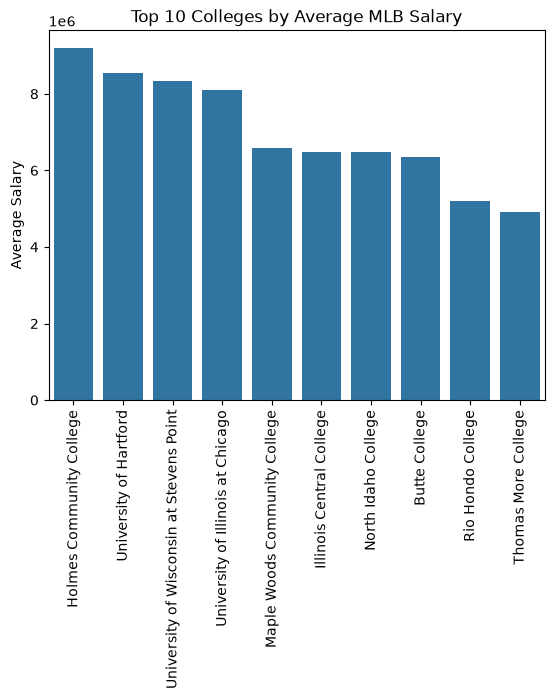

In [40]:
# 1. Group by schoolID to get the average salary
school_groupings = matched_data.groupby('schoolID')['salary'].mean().reset_index()

# 3. Merge with the 'schools' dataframe to pull in the actual school names
school_names_merged = pd.merge(school_groupings, schools[['schoolID', 'name_full']], on='schoolID', how='left')

# 4. Fill the resulting NaN for 'Did Not Attend'
school_names_merged['name_full'] = school_names_merged['name_full'].fillna('Did Not Attend')

# 5. Sort values from highest to lowest salary and grab the top 10
top_10_schools = school_names_merged.sort_values(by='salary', ascending=False).head(10)

# 6. Plot the bar chart using Seaborn
chart = sns.barplot(data=top_10_schools, x='name_full', y='salary')

# # 7. Format the chart directly through the Seaborn axes object
chart.set_title('Top 10 Colleges by Average MLB Salary')
chart.set_ylabel('Average Salary')
chart.set_xlabel('') 

# Rotate the x-axis labels so they don't overlap
chart.tick_params(axis='x', rotation=90)

## Analysis Technique 2

## Analysis Technique 3

## Analysis Technique 4